# Training des BiLSTM-Regressors auf synthetischen LLM-Zwischenstufen

Dieses Notebook trainiert ein kontinuierliches Komplexitäts-Regressionsmodell (`BiLSTMRegressor`) auf den vom LLM erzeugten synthetischen Zwischenstufen (Stufen `0.0`, `0.25`, `0.50`, `0.75`, `1.0`).

## 1. Datenarchitektur
Jeder Artikel aus `corpus_final_with_steps.json` enthält 5 Sprachstufen:
- **Stufe 0.00:** Leichte Sprache (`ls_text`)
- **Stufe 0.25:** Synthetische Stufe nahe an Leichter Sprache (`intermediate_steps['0.25']`)
- **Stufe 0.50:** Synthetische Einfache Sprache (`intermediate_steps['0.50']`)
- **Stufe 0.75:** Synthetische Stufe nahe an Alltagssprache (`intermediate_steps['0.75']`)
- **Stufe 1.00:** Alltagssprache (`as_text`)

Das Dataset flacht diese Struktur in einzelne `(text, target)` Paare aus.

In [1]:
import os
import sys

# Arbeitsverzeichnis auf das Root-Verzeichnis des Repositories setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # System-Root erreicht, Abbruch
        break
    os.chdir("..")

print("Aktuelles Arbeitsverzeichnis:", os.getcwd())

Aktuelles Arbeitsverzeichnis: /home/fiete/master-thesis


In [2]:
import torch
print("CUDA verfügbar:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Keine GPU")

# Set seed for reproducibility
def set_seed(seed=42):
    import random
    import numpy as np
    import torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Globaler Seed auf {seed} gesetzt.")

set_seed(42)


CUDA verfügbar: True
Device Name: NVIDIA GeForce RTX 4090
Globaler Seed auf 42 gesetzt.


In [3]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PARAMS (Hier anpassen)
# ==============================================================================
CORPUS_WITH_STEPS_PATH = "data/corpus/final_with_steps.json"
LH_WITH_STEPS_PATH = "data/lebenshilfe/lebenshilfe_dataset_with_steps.json"
MODEL_SAVE_PATH = "results/models/bilstm_synthetic_regression.pt"
VOCAB_SAVE_PATH = "data/vocabs/synthetic_vocab.json"

EPOCHS = 15
MAX_SEQ_LEN = 256


In [4]:
import json
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from tqdm.notebook import tqdm
from collections import Counter
from scipy.stats import pearsonr, spearmanr

# Reproduzierbarkeit
SEED = 42
set_seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Pfade
# CORPUS_WITH_STEPS_PATH = "data/corpus/final_with_steps.json"  # -> Zentral oben definiert
# LH_WITH_STEPS_PATH = "data/lebenshilfe/lebenshilfe_dataset_with_steps.json"  # -> Zentral oben definiert
# MODEL_SAVE_PATH = "results/models/bilstm_synthetic_regression.pt"  # -> Zentral oben definiert
# VOCAB_SAVE_PATH = "data/vocabs/synthetic_vocab.json"  # -> Zentral oben definiert

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {device}")

Globaler Seed auf 42 gesetzt.
Nutze Device: cuda


## 2. Dataset-Klasse für synthetische Stufen

In [5]:
def load_flattened_samples(json_path):
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"Datei nicht gefunden: {json_path}")
        
    with open(json_path, "r", encoding="utf-8") as f:
        articles = json.load(f)
        
    samples = []
    for art_idx, art in enumerate(articles):
        ls_text = art.get("ls_text", "").strip()
        as_text = art.get("as_text", "").strip()
        steps = art.get("intermediate_steps", {})
        
        if ls_text:
            samples.append({"text": ls_text, "target": 0.0, "article_id": art_idx, "stage": "0.00 (LS)"})
        if as_text:
            samples.append({"text": as_text, "target": 1.0, "article_id": art_idx, "stage": "1.00 (AS)"})
            
        for step_str, step_text in steps.items():
            try:
                target_val = float(step_str)
                if step_text and step_text.strip():
                    samples.append({
                        "text": step_text.strip(),
                        "target": target_val,
                        "article_id": art_idx,
                        "stage": f"{target_val:.2f}"
                    })
            except ValueError:
                continue
                
    return samples, articles

raw_samples, raw_articles = load_flattened_samples(CORPUS_WITH_STEPS_PATH)
print(f"Anzahl geladener Artikel: {len(raw_articles)}")
print(f"Anzahl ausgeflachter Text-Samples: {len(raw_samples)}")

# Verteilung der Stufen anzeigen
stage_counts = Counter(s["stage"] for s in raw_samples)
for stage, count in sorted(stage_counts.items()):
    print(f"  Stufe {stage}: {count} Samples")

Anzahl geladener Artikel: 1476
Anzahl ausgeflachter Text-Samples: 7380
  Stufe 0.00 (LS): 1476 Samples
  Stufe 0.25: 1476 Samples
  Stufe 0.50: 1476 Samples
  Stufe 0.75: 1476 Samples
  Stufe 1.00 (AS): 1476 Samples


## 3. Tokenisierung & Vokabular-Aufbau

In [6]:
nlp = spacy.blank("de")

def build_vocab(samples, min_freq=2):
    counter = Counter()
    for sample in tqdm(samples, desc="Baue Vokabular"):
        doc = nlp(sample["text"])
        tokens = [t.text.lower() for t in doc if not t.is_space]
        counter.update(tokens)
        
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, count in counter.items():
        if count >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(raw_samples, min_freq=2)
print(f"Vokabulargröße: {len(vocab)} Wörter")

# Vokabular abspeichern
with open(VOCAB_SAVE_PATH, "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)
print(f"Vokabular gespeichert unter: {VOCAB_SAVE_PATH}")

Baue Vokabular:   0%|          | 0/7380 [00:00<?, ?it/s]

Vokabulargröße: 52603 Wörter
Vokabular gespeichert unter: data/vocabs/synthetic_vocab.json


## 4. PyTorch Dataset & DataLoader

In [7]:
class SyntheticStepDataset(Dataset):
    def __init__(self, samples, vocab, nlp_spacy, max_len=MAX_SEQ_LEN):
        self.samples = samples
        self.vocab = vocab
        self.nlp = nlp_spacy
        self.max_len = max_len
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        item = self.samples[idx]
        doc = self.nlp(item["text"])
        tokens = [t.text.lower() for t in doc if not t.is_space][:self.max_len]
        
        token_ids = [self.vocab.get(t, self.vocab["<UNK>"]) for t in tokens]
        if not token_ids:
            token_ids = [self.vocab["<PAD>"]]
            
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(item["target"], dtype=torch.float32)

def pad_collate_fn(batch):
    sequences, targets = zip(*batch)
    lengths = [len(seq) for seq in sequences]
    padded_seqs = torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=0)
    targets = torch.tensor(targets, dtype=torch.float32)
    return padded_seqs, targets

# Split auf Artikel-Ebene (80% Train, 20% Val)
unique_art_ids = list(set(s["article_id"] for s in raw_samples))
random.shuffle(unique_art_ids)
split_idx = int(0.8 * len(unique_art_ids))
train_art_ids = set(unique_art_ids[:split_idx])
val_art_ids = set(unique_art_ids[split_idx:])

train_samples = [s for s in raw_samples if s["article_id"] in train_art_ids]
val_samples = [s for s in raw_samples if s["article_id"] in val_art_ids]

print(f"Train-Samples: {len(train_samples)} (aus {len(train_art_ids)} Artikeln)")
print(f"Val-Samples: {len(val_samples)} (aus {len(val_art_ids)} Artikeln)")

train_ds = SyntheticStepDataset(train_samples, vocab, nlp, max_len=MAX_SEQ_LEN)
val_ds = SyntheticStepDataset(val_samples, vocab, nlp, max_len=MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=pad_collate_fn)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=pad_collate_fn)

Train-Samples: 5900 (aus 1180 Artikeln)
Val-Samples: 1480 (aus 296 Artikeln)


## 5. Modelldefinition (`BiLSTMRegressor`)

In [8]:
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out).squeeze(-1)

model = BiLSTMRegressor(vocab_size=len(vocab), embed_dim=128, hidden_dim=128, dropout=0.3).to(device)
print(model)

BiLSTMRegressor(
  (embedding): Embedding(52603, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (sigmoid): Sigmoid()
)


## 6. Training des Regressionsmodells

In [9]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

# EPOCHS = 15  # -> Zentral oben definiert
best_val_loss = float("inf")
train_losses = []
val_losses = []

for epoch in range(1, EPOCHS + 1):
    # Train-Schleife
    model.train()
    total_train_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * x_batch.size(0)
        
    avg_train_loss = total_train_loss / len(train_ds)
    train_losses.append(avg_train_loss)
    
    # Val-Schleife
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            total_val_loss += loss.item() * x_batch.size(0)
            
    avg_val_loss = total_val_loss / len(val_ds)
    val_losses.append(avg_val_loss)
    scheduler.step()
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        saved_str = " -> [Modell gespeichert]"
    else:
        saved_str = ""
        
    print(f"Epoche {epoch:02d}/{EPOCHS:02d} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}{saved_str}")

Epoche 01/15 | Train MSE: 0.0974 | Val MSE: 0.0788 -> [Modell gespeichert]
Epoche 02/15 | Train MSE: 0.0693 | Val MSE: 0.0547 -> [Modell gespeichert]
Epoche 03/15 | Train MSE: 0.0705 | Val MSE: 0.1093
Epoche 04/15 | Train MSE: 0.0901 | Val MSE: 0.0806
Epoche 05/15 | Train MSE: 0.0632 | Val MSE: 0.0654
Epoche 06/15 | Train MSE: 0.0468 | Val MSE: 0.0383 -> [Modell gespeichert]
Epoche 07/15 | Train MSE: 0.0376 | Val MSE: 0.0370 -> [Modell gespeichert]
Epoche 08/15 | Train MSE: 0.0323 | Val MSE: 0.0320 -> [Modell gespeichert]
Epoche 09/15 | Train MSE: 0.0261 | Val MSE: 0.0332
Epoche 10/15 | Train MSE: 0.0226 | Val MSE: 0.0305 -> [Modell gespeichert]
Epoche 11/15 | Train MSE: 0.0216 | Val MSE: 0.0297 -> [Modell gespeichert]
Epoche 12/15 | Train MSE: 0.0200 | Val MSE: 0.0272 -> [Modell gespeichert]
Epoche 13/15 | Train MSE: 0.0194 | Val MSE: 0.0276
Epoche 14/15 | Train MSE: 0.0193 | Val MSE: 0.0271 -> [Modell gespeichert]
Epoche 15/15 | Train MSE: 0.0181 | Val MSE: 0.0274


## 7. Lernkurve visualisieren

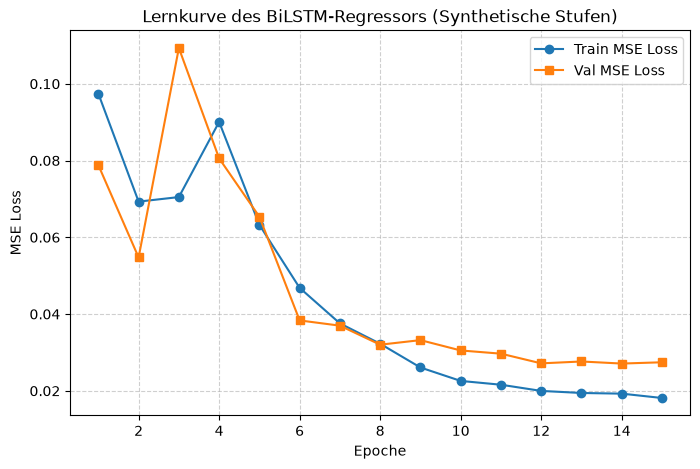

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train MSE Loss", marker="o")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Val MSE Loss", marker="s")
plt.title("Lernkurve des BiLSTM-Regressors (Synthetische Stufen)")
plt.xlabel("Epoche")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## 8. Out-of-Domain Evaluierung auf dem Lebenshilfe-Set

In [11]:
# Bestes Modell laden
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
model.eval()

lh_samples, lh_articles = load_flattened_samples(LH_WITH_STEPS_PATH)
lh_ds = SyntheticStepDataset(lh_samples, vocab, nlp, max_len=MAX_SEQ_LEN)
lh_loader = DataLoader(lh_ds, batch_size=32, shuffle=False, collate_fn=pad_collate_fn)

all_preds = []
all_targets = []

with torch.no_grad():
    for x_batch, y_batch in lh_loader:
        x_batch = x_batch.to(device)
        preds = model(x_batch).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

mse = np.mean((all_preds - all_targets) ** 2)
mae = np.mean(np.abs(all_preds - all_targets))
pearson_r, _ = pearsonr(all_preds, all_targets)
spearman_rho, _ = spearmanr(all_preds, all_targets)

print("=" * 60)
print("OUT-OF-DOMAIN EVALUIERUNG: LEBENSHILFE SYNTHETIK-SET")
print("=" * 60)
print(f"Anzahl Evaluierungssamples: {len(all_targets)}")
print(f"MSE (Mean Squared Error):  {mse:.4f}")
print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"Pearson Korrelation r:    {pearson_r:.4f}")
print(f"Spearman Korrelation rho: {spearman_rho:.4f}")
print("=" * 60)

OUT-OF-DOMAIN EVALUIERUNG: LEBENSHILFE SYNTHETIK-SET
Anzahl Evaluierungssamples: 245
MSE (Mean Squared Error):  0.0906
MAE (Mean Absolute Error): 0.2148
Pearson Korrelation r:    0.7145
Spearman Korrelation rho: 0.7086


## 9. Monotonie & Stufen-Verteilung visualisieren

/tmp/ipykernel_691255/2790054184.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eval, x="Zielstufe", y="Vorhergesagter Score", palette="viridis")


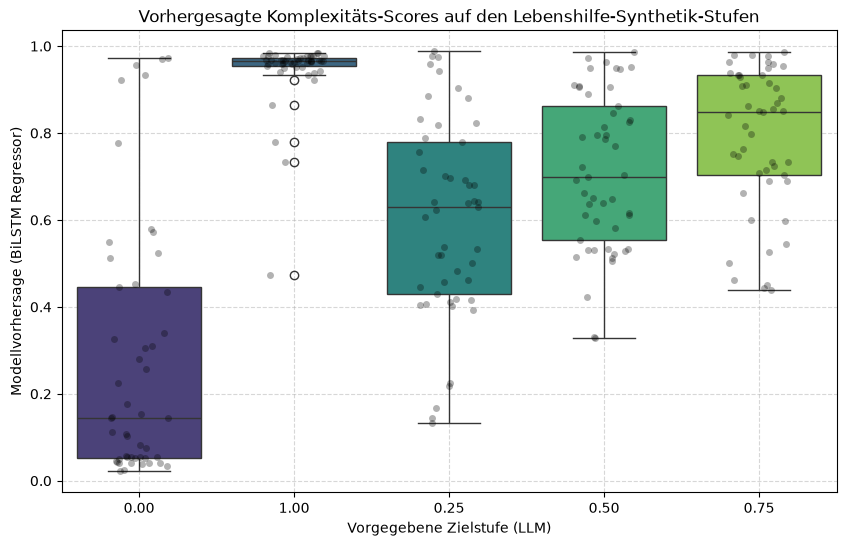

In [12]:
df_eval = pd.DataFrame({
    "Zielstufe": [f"{t:.2f}" for t in all_targets],
    "Vorhergesagter Score": all_preds
})

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_eval, x="Zielstufe", y="Vorhergesagter Score", palette="viridis")
sns.stripplot(data=df_eval, x="Zielstufe", y="Vorhergesagter Score", color="black", alpha=0.3, jitter=0.2)
plt.title("Vorhergesagte Komplexitäts-Scores auf den Lebenshilfe-Synthetik-Stufen")
plt.xlabel("Vorgegebene Zielstufe (LLM)")
plt.ylabel("Modellvorhersage (BiLSTM Regressor)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()